In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Yogya kumar\Downloads\DATA SET\smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

### Handle Missing Values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()  

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [7]:
 df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [8]:
# Age of the Customers
df["Age"] = 2026 - df["Year_Birth"]

In [9]:
# Total days from JOining
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [10]:
# Total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [13]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [14]:
# Marital Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Absurb": "Alone", "YOLO": "Alone"
})

In [15]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       794
Absurd        2
Name: count, dtype: int64

# Drop Columns

In [16]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

# Outliers

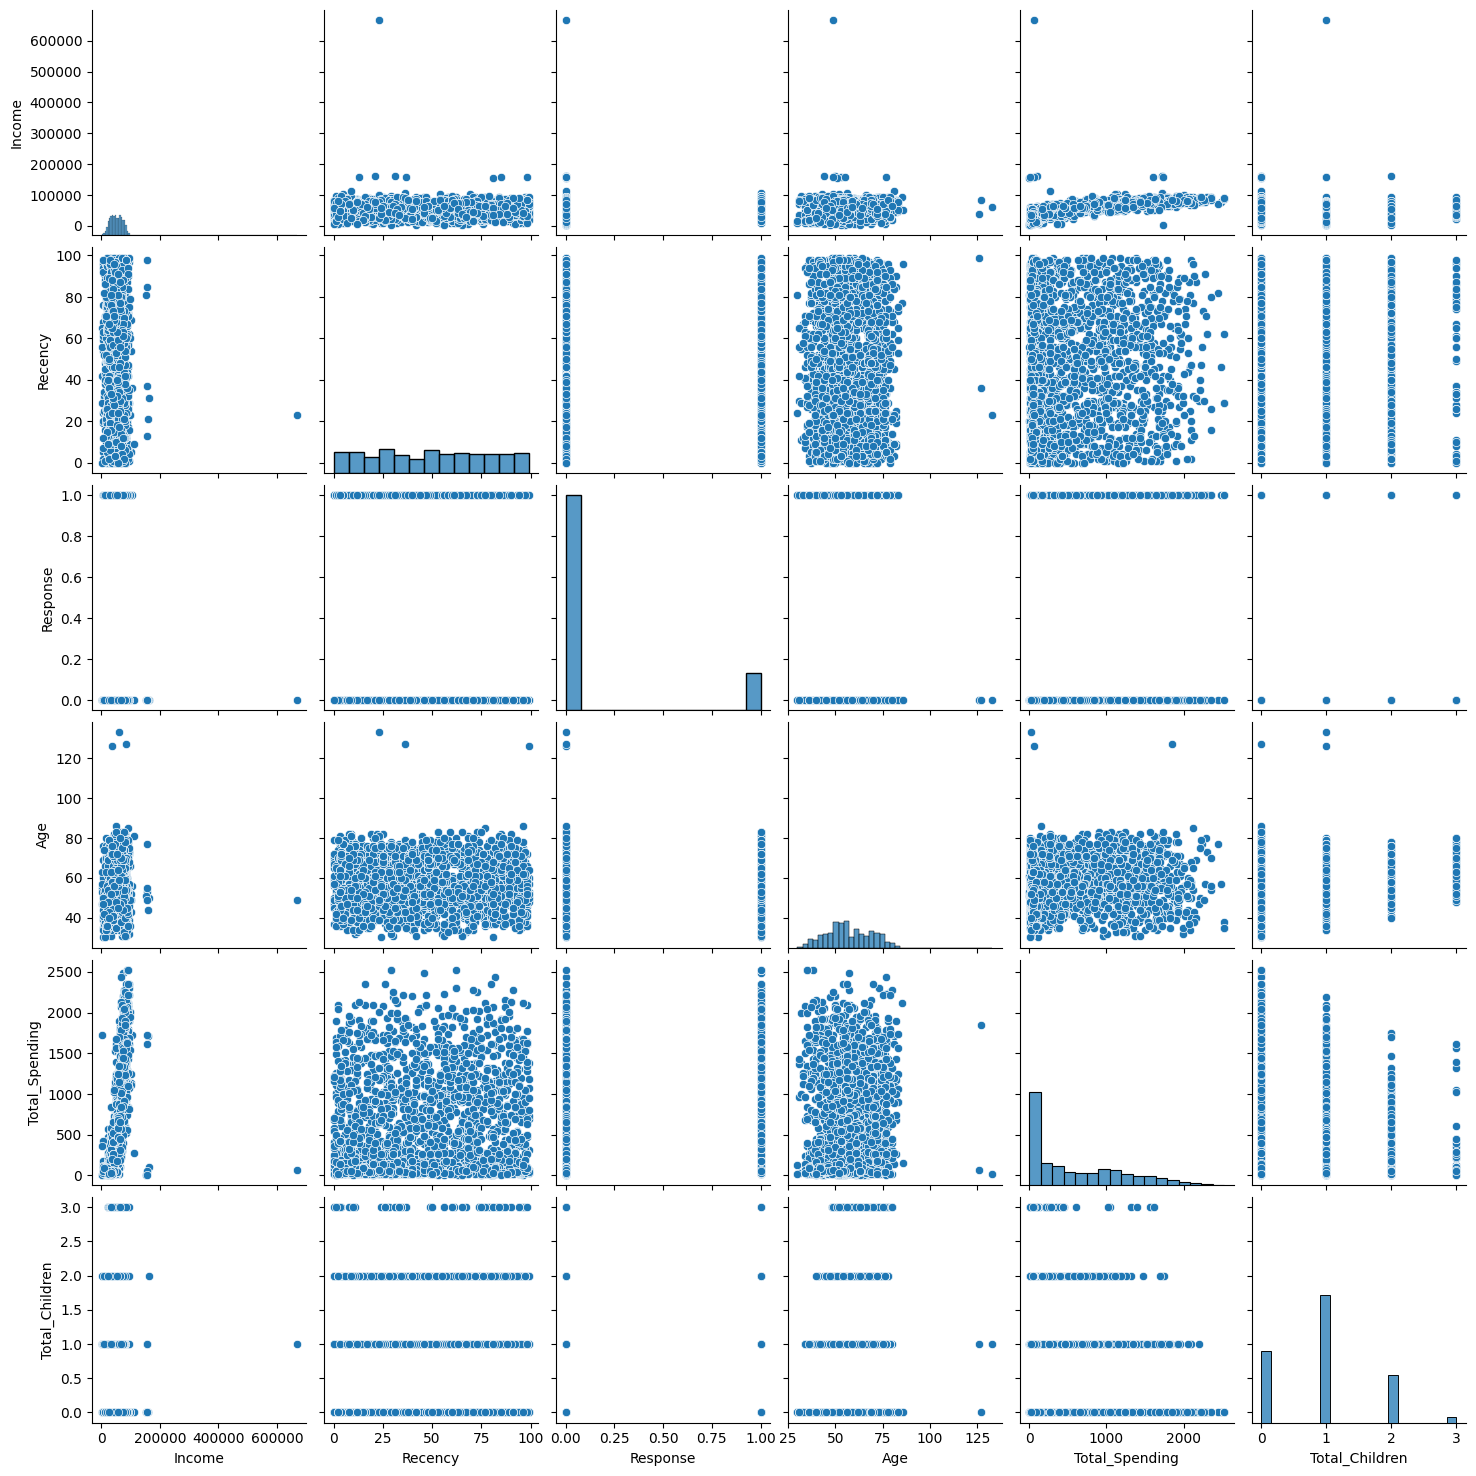

In [17]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Pair Plot - that shows all the relative plots among all the features
sns.pairplot(df_cleaned[cols])

In [18]:
# Removing Outliers

print("Data size with Outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000) ]

print("Data size without outliers: ", len(df_cleaned))

Data size with Outliers:  2240
Data size without outliers:  2236


# Heatmap

In [19]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

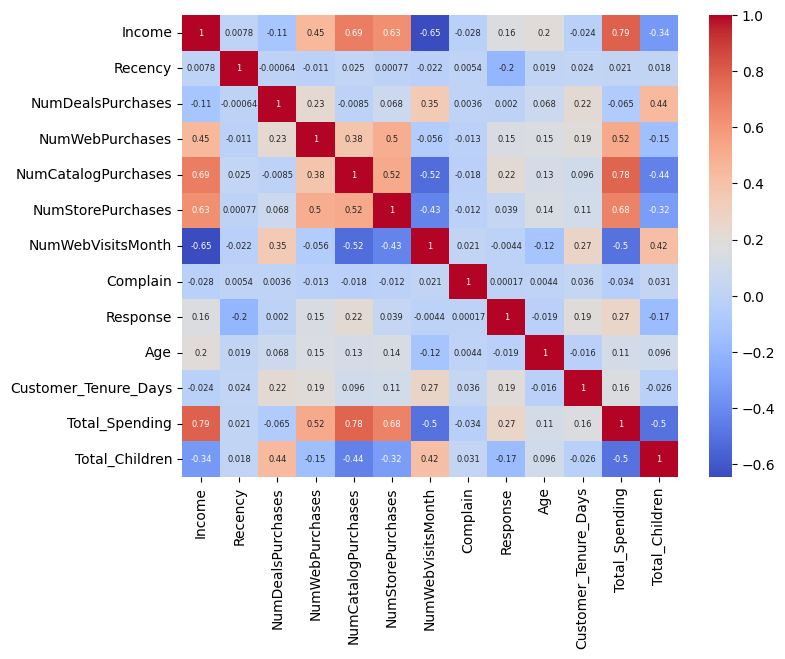

In [20]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

# Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [23]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [24]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis=1)

# Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
X = df_encoded

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [28]:
# 3D

from sklearn.decomposition import PCA

In [29]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D Projection')

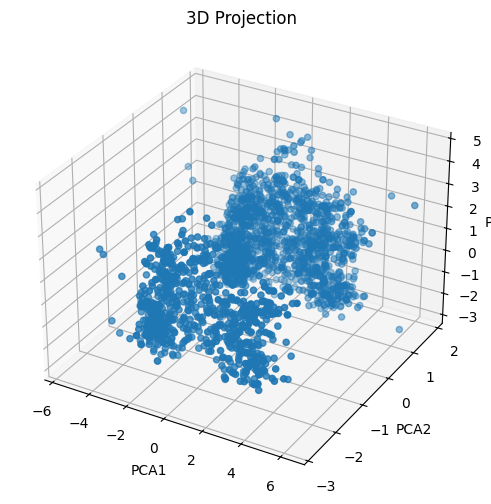

In [30]:
# Plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")


# Analyse K value

### 1. Elbow Method

In [31]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [32]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction="decreasing")
optimal_k = knee.elbow

In [33]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

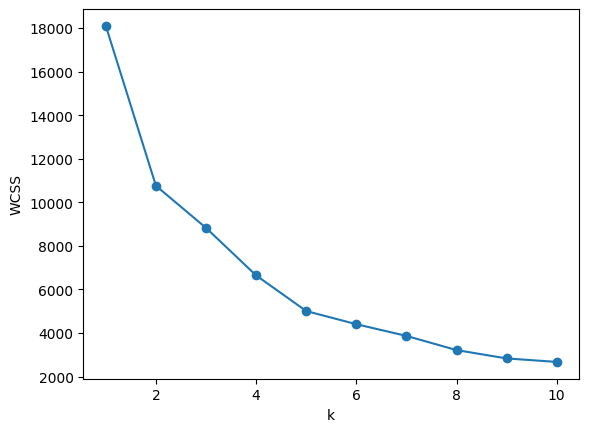

In [34]:
# Plot

plt.plot(range(1, 11), wcss, marker = 'o')
plt.xlabel('k')
plt.ylabel("WCSS")

# Shilhouette Score

Text(0, 0.5, 'Silhoutter Score')

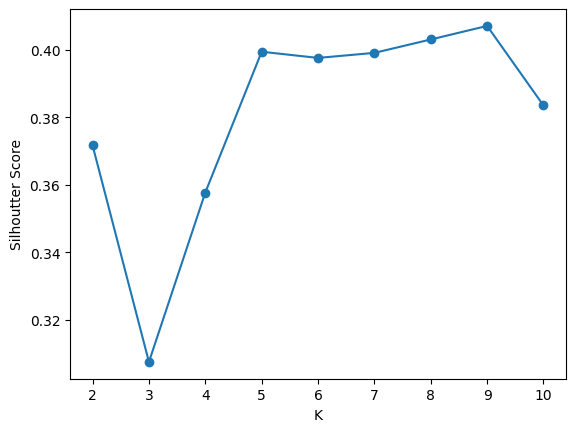

In [35]:
from sklearn.metrics import silhouette_score

scores = []

for k in range (2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.plot(range(2, 11), scores, marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhoutter Score")

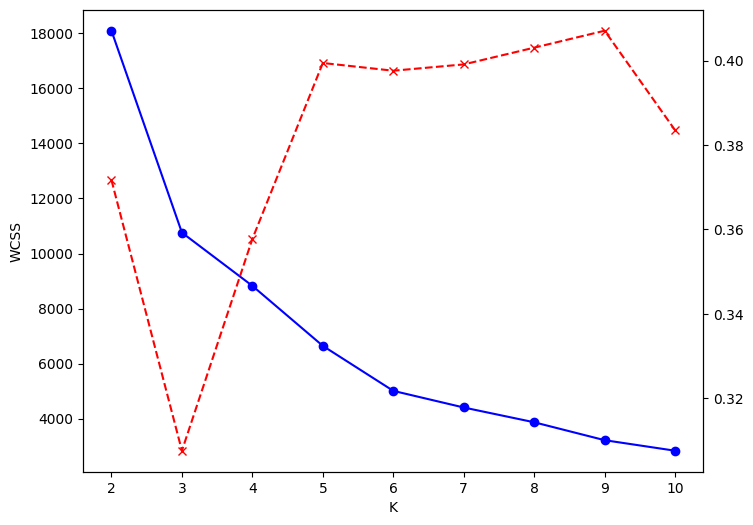

In [36]:
# Combined plot
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_label("SS")

# Clustering

In [37]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_means = kmeans.fit_predict(X_pca)

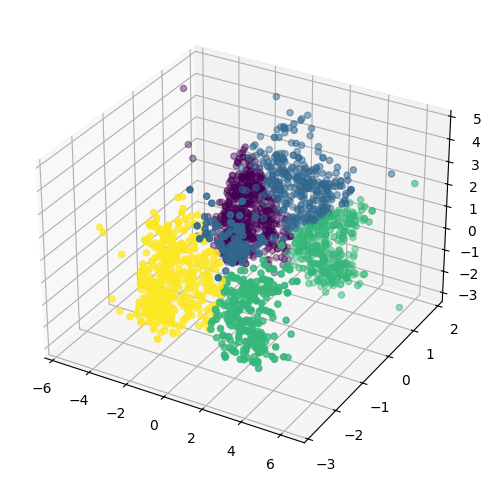

In [38]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_means)

# Agglomerative Clustering

In [39]:
from sklearn.cluster import AgglomerativeClustering

In [40]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

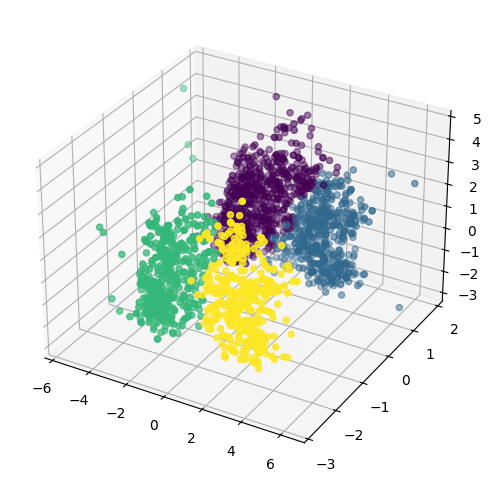

In [41]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Characterization of Clusters

In [49]:
X["cluster"] = labels_agg

In [50]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Absurd,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

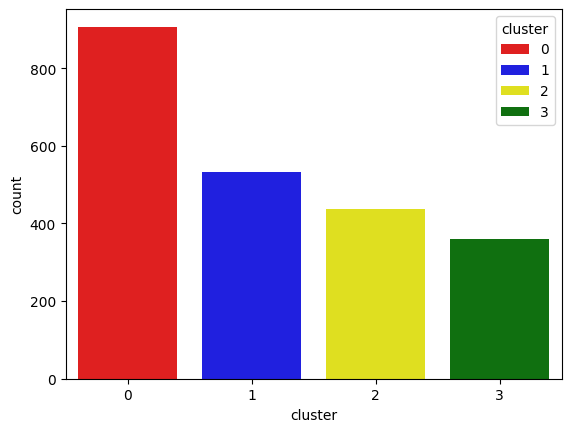

In [51]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X['cluster'], palette=pal,hue=X['cluster'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

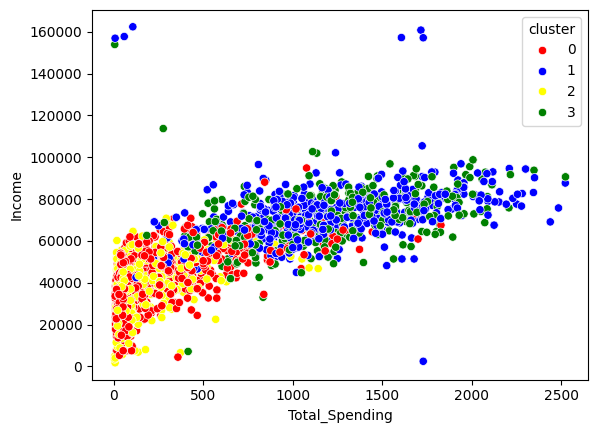

In [53]:
# Income & Spending Patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

# Cluster Summary

In [54]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39940.962514  49.289967           2.714443         3.267916   
1        72489.063910  48.563910           1.751880         5.501880   
2        36658.799771  48.221968           2.574371         2.684211   
3        70431.984722  50.580556           1.894444         5.766667   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.065050           4.269019           6.433297  0.009923   
1                   5.351504           8.462406           3.355263  0.007519   
2                   0.803204           3.581236           6.693364  0.011442   
3                   4.975000           8.388889           3.744444  0.005556   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

In [55]:
import os
print(os.getcwd())

C:\Users\Yogya kumar\AiMl\Pandas01\Supervised


# Cluster Interpretation & Business Recommendations

Ab tak humne clusters ban liye hain, ab har cluster ko naam (persona) denge aur uske hisaab se marketing recommendation likhenge.

Interpretation `cluster_summary` table ke in columns ko compare karke ki gayi hai:
- **Income / Total_Spending** — high ya low spender
- **NumStorePurchases / NumWebVisitsMonth** — kaise shop karte hain
- **Response** — campaign/offer pe react karte hain ya nahi
- **Total_Children / Living_With** — household profile

In [ ]:
# Persona names based on cluster_summary comparison

cluster_personas = {
    0: "Budget-Conscious Window Shoppers",
    1: "Premium Loyal Customers",
    2: "Budget, Least Engaged",
    3: "Premium & Campaign Responsive"
}

cluster_recommendations = {
    0: "High web visits but low purchase & low spend -> send targeted discount coupons and deal alerts to convert browsing into buying.",
    1: "High income, high spend, buys via store/catalog, low web browsing -> offer a premium loyalty program and early access to new products; low churn risk.",
    2: "Lowest spend and lowest campaign response -> highest churn risk; needs re-engagement campaigns and win-back offers.",
    3: "High income, high spend AND highest campaign response rate -> best ROI segment; prioritise premium campaigns and upsell offers here first."
}

cluster_summary_named = cluster_summary.copy()
cluster_summary_named.insert(0, "Persona", cluster_summary_named.index.map(cluster_personas))
cluster_summary_named.insert(1, "Recommended_Action", cluster_summary_named.index.map(cluster_recommendations))

cluster_summary_named[["Persona", "Recommended_Action", "Income", "Total_Spending", "Response"]]

### Cluster labels map on the original dataframe
Add persona names back onto the customer-level data, so each row (customer) has a readable segment label.

In [ ]:
X["Persona"] = X["cluster"].map(cluster_personas)
X[["cluster", "Persona"]].head()

# Predict Cluster for a New Customer (optional)

Ye function ek naye customer ka raw data leta hai, wahi preprocessing steps (age, spend total, encoding, scaling, PCA) apply karta hai, aur phir sabse nazdeek cluster centroid (Euclidean distance) ke aadhar par uska cluster/persona predict karta hai.

Note: KMeans/Agglomerative ka koi built-in `.predict()` naya point ke liye reliable nahi hota (Agglomerative me predict hota hi nahi), isliye hum khud nearest-centroid approach use kar rahe hain — ye standard practice hai jab clustering ko naye data pe deploy karna ho.

In [ ]:
import numpy as np

# Centroid (mean PCA position) of each existing cluster
cluster_centroids = pd.DataFrame(X_pca, columns=["PCA1", "PCA2", "PCA3"])
cluster_centroids["cluster"] = labels_agg
cluster_centroids = cluster_centroids.groupby("cluster").mean()


def predict_new_customer(raw_customer: dict):
    """
    raw_customer: dict with same raw columns as the original CSV
    (Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome,
     Dt_Customer, Recency, MntWines, MntFruits, MntMeatProducts,
     MntFishProducts, MntSweetProducts, MntGoldProds, NumDealsPurchases,
     NumWebPurchases, NumCatalogPurchases, NumStorePurchases,
     NumWebVisitsMonth, Complain, Response)
    Returns: (cluster_number, persona_name)
    """
    row = pd.DataFrame([raw_customer])

    # Same feature engineering as training
    row["Age"] = 2026 - row["Year_Birth"]
    row["Dt_Customer"] = pd.to_datetime(row["Dt_Customer"], dayfirst=True)
    row["Customer_Tenure_Days"] = (reference_date - row["Dt_Customer"]).dt.days
    row["Total_Spending"] = (row["MntWines"] + row["MntFruits"] + row["MntMeatProducts"]
                              + row["MntFishProducts"] + row["MntSweetProducts"] + row["MntGoldProds"])
    row["Total_Children"] = row["Kidhome"] + row["Teenhome"]
    row["Education"] = row["Education"].replace({
        "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
        "Graduation": "Graduate",
        "Master": "Postgraduate", "PhD": "Postgraduate"
    })
    row["Living_With"] = row["Marital_Status"].replace({
        "Married": "Partner", "Together": "Partner",
        "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Absurb": "Alone", "YOLO": "Alone"
    })

    row_cleaned = row.drop(columns=["Year_Birth", "Marital_Status", "Kidhome", "Teenhome",
                                     "Dt_Customer", "MntWines", "MntFruits", "MntMeatProducts",
                                     "MntFishProducts", "MntSweetProducts", "MntGoldProds"])

    enc_row = ohe.transform(row_cleaned[["Education", "Living_With"]])
    enc_row_df = pd.DataFrame(enc_row.toarray(), columns=ohe.get_feature_names_out(["Education", "Living_With"]))
    row_encoded = pd.concat([row_cleaned.drop(columns=["Education", "Living_With"]).reset_index(drop=True), enc_row_df], axis=1)

    # match training column order (X before cluster/Persona columns were added)
    row_encoded = row_encoded.reindex(columns=scaler.feature_names_in_, fill_value=0)

    row_scaled = scaler.transform(row_encoded)
    row_pca = pca.transform(row_scaled)

    distances = np.linalg.norm(cluster_centroids.values - row_pca, axis=1)
    predicted_cluster = int(np.argmin(distances))

    return predicted_cluster, cluster_personas[predicted_cluster]


# Example usage:
# sample_customer = {
#     "Year_Birth": 1978, "Education": "Graduation", "Marital_Status": "Married",
#     "Income": 65000, "Kidhome": 0, "Teenhome": 1, "Dt_Customer": "15-06-2013",
#     "Recency": 20, "MntWines": 500, "MntFruits": 40, "MntMeatProducts": 300,
#     "MntFishProducts": 50, "MntSweetProducts": 30, "MntGoldProds": 60,
#     "NumDealsPurchases": 2, "NumWebPurchases": 4, "NumCatalogPurchases": 6,
#     "NumStorePurchases": 7, "NumWebVisitsMonth": 4, "Complain": 0, "Response": 1
# }
# predict_new_customer(sample_customer)